Reading state spending data...
Merging datasets and creating features...
Calculating school metrics...
Building and training the model...
Model Evaluation:
R² Score: 0.828
RMSE: 1.277

Generating state-level recommendations...

Top 5 Important Features:
        Feature  Importance
  K-12 Spending    0.626024
     Efficiency    0.299729
      Pass_Rate    0.045690
     Start_Rate    0.014542
Completion_Rate    0.006341

Final Course Recommendations by State (Max 30 Courses):
               State K-12 Spending  Current_Course_Count  Recommended_Courses Change_From_Current Start_Rate Pass_Rate Success_Score
            New York       $33,437                  20.0                   23                  +3      94.7%     88.8%         86.6%
          New Jersey       $26,558                  16.0                   20                  +4      91.3%     80.9%         82.7%
             Vermont       $26,974                  17.0                   20                  +3      89.0%     82.5%    

<ipython-input-2-9b30d8f57de9>:276: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  display_results['K-12 Spending'] = display_results['K-12 Spending'].apply(lambda x: f"${x:,.0f}")
<ipython-input-2-9b30d8f57de9>:277: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  display_results['Start_Rate'] = display_results['Start_Rate'].apply(lambda x: f"{x*100:.1f}%")
<ipython-input-2-9b30d8f57de9>:278: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,


Model Summary:
- The model recommends course counts ranging from 8 to 23 per school
- 32 states should increase their course offerings
- 0 states reached the maximum course limit of 30
- The average recommended increase is 0.2 courses per school

Analysis complete!


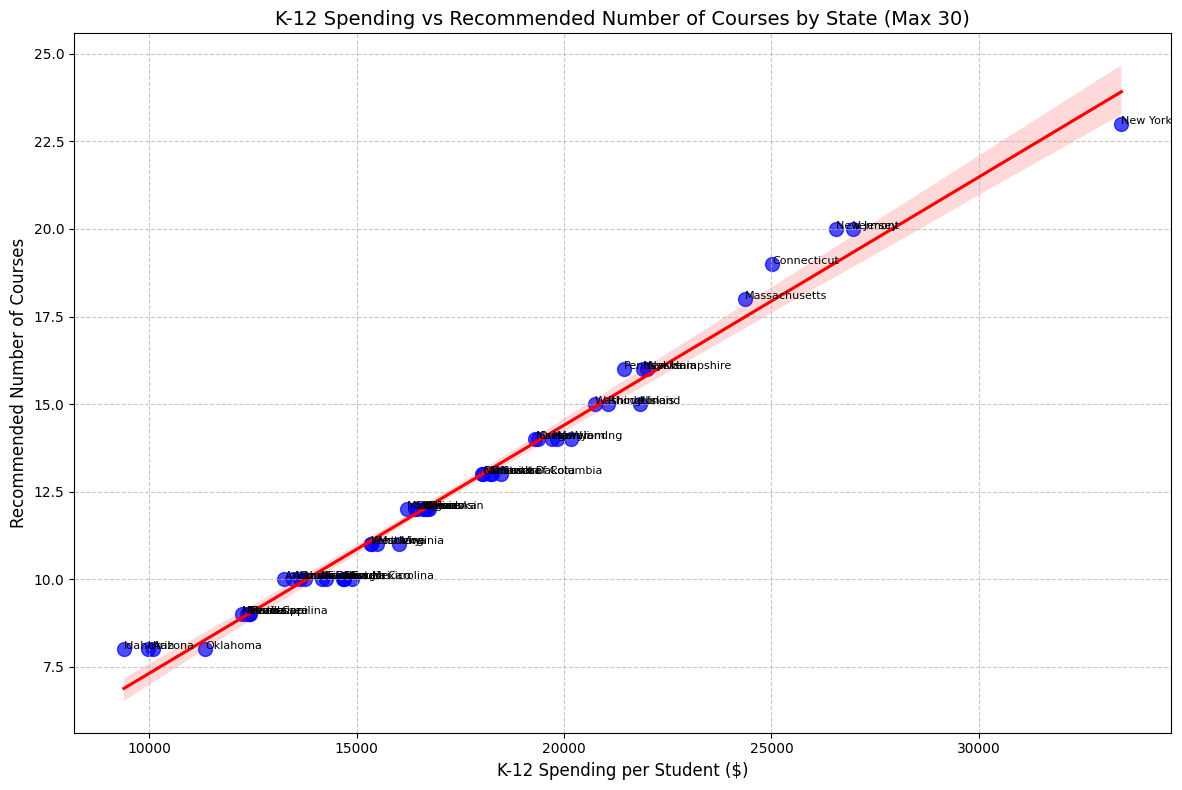

<Figure size 1600x1000 with 0 Axes>

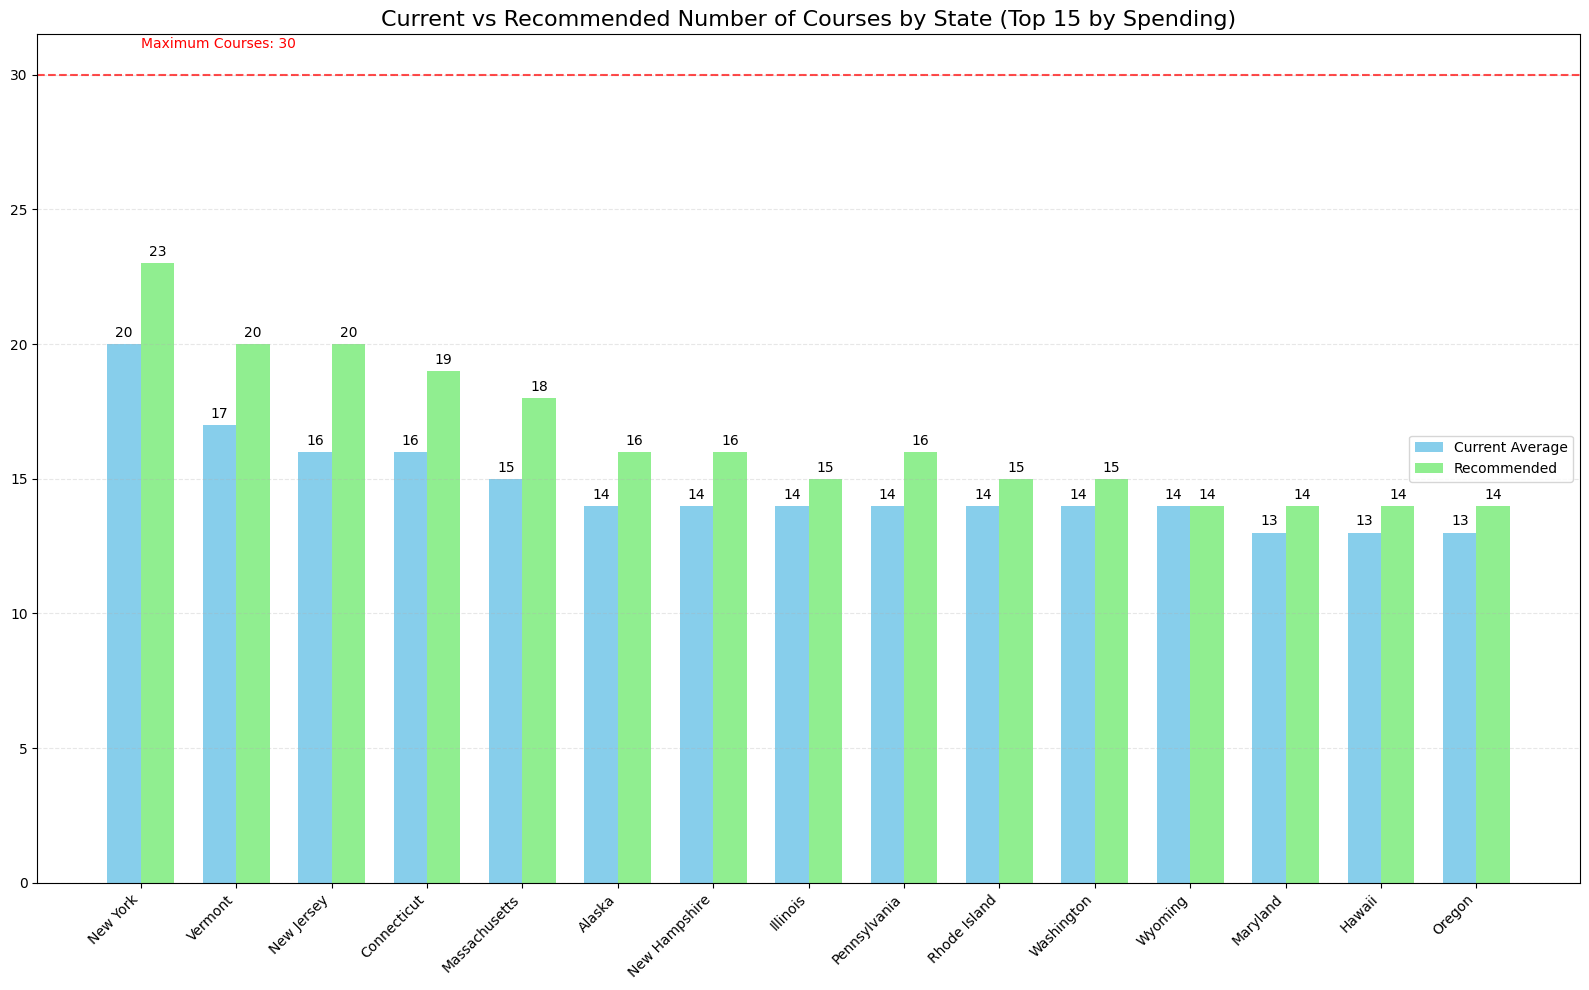

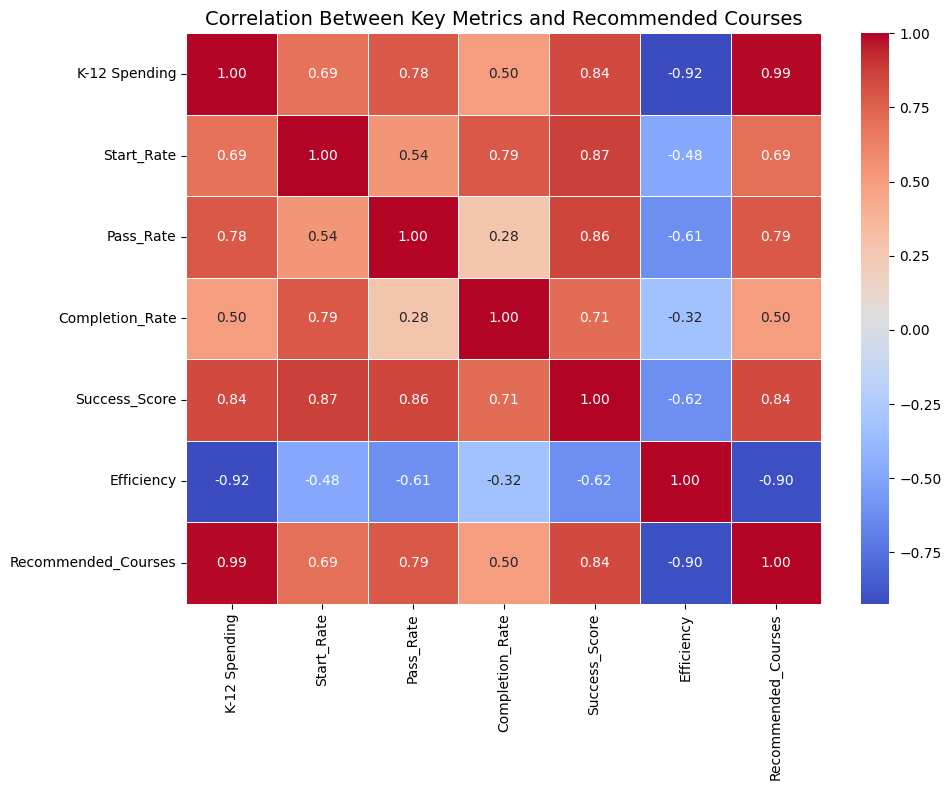

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Read state spending data directly from CSV file
print("Reading state spending data...")
state_spending = pd.read_csv("/content/staterevdata(Sheet2).csv")
# Clean currency format
state_spending['K-12 Spending'] = state_spending['K-12 Spending'].str.replace('$', '').str.replace(',', '').str.strip().astype(float)

# Define maximum number of courses constraint
MAX_COURSES = 30

# For simulation purposes, we'll still generate sample data for the other datasets
# In a real implementation, you would read these from the actual CSV files
np.random.seed(42)

# Simulate high school data - one school per state to simplify
school_count = len(state_spending)
high_schools = pd.DataFrame({
    'School Id': [f'SCH{i:03d}' for i in range(1, school_count + 1)],
    'Name': [f'High School {i}' for i in range(1, school_count + 1)],
    'State': state_spending['State'].values,
    'Locale': np.random.choice(['Urban', 'Suburban', 'Rural'], size=school_count),
    'Time Zone': np.random.choice(['Eastern', 'Central', 'Mountain', 'Pacific'], size=school_count)
})

# Simulate classroom data with varying course counts
# Higher spending states have more courses initially
classrooms = []
classroom_id = 1

for idx, row in high_schools.iterrows():
    state = row['State']
    spending = state_spending[state_spending['State'] == state]['K-12 Spending'].values[0]

    # Scale initial course count with spending (between 5 and 20)
    course_count = int(5 + (spending / state_spending['K-12 Spending'].max()) * 15)

    for _ in range(course_count):
        classrooms.append({
            'Classroom Id': f'CLS{classroom_id:03d}',
            'School Id': row['School Id'],
            'Course_Name__c': np.random.choice(['College Algebra', 'Intro to Psychology', 'Data Science',
                                               'English Composition', 'Computer Science']),
            'University__c': np.random.choice(['Howard University', 'Stanford University', 'Princeton University',
                                              'Yale University', 'Wesleyan University']),
            'Term_Name__c': np.random.choice(['Fall 2022', 'Spring 2023', 'Fall 2023', 'Spring 2024']),
            'Status__c': np.random.choice(['Archived', 'Dropped'], p=[0.9, 0.1])
        })
        classroom_id += 1

classrooms = pd.DataFrame(classrooms)

# Simulate student seat data - more students in wealthier states
school_state_map = dict(zip(high_schools['School Id'], high_schools['State']))
classroom_school_map = dict(zip(classrooms['Classroom Id'], classrooms['School Id']))

# Calculate seats per classroom (more in higher spending states)
seats_per_classroom = []
for _, classroom in classrooms.iterrows():
    school_id = classroom['School Id']
    state = school_state_map[school_id]
    spending = state_spending[state_spending['State'] == state]['K-12 Spending'].values[0]

    # Scale seats with spending
    base_seats = 15
    spending_factor = spending / state_spending['K-12 Spending'].mean()
    seats = int(base_seats * spending_factor)
    seats = max(10, min(30, seats)) # Between 10-30 seats

    seats_per_classroom.append((classroom['Classroom Id'], seats))

# Create student seats
student_seats = []
student_id = 1

for classroom_id, seat_count in seats_per_classroom:
    school_id = classroom_school_map[classroom_id]
    state = school_state_map[school_id]
    spending = state_spending[state_spending['State'] == state]['K-12 Spending'].values[0]
    spending_factor = spending / state_spending['K-12 Spending'].mean()

    for _ in range(seat_count):
        # Higher spending correlates with better outcomes
        dns_prob = max(0.05, 0.25 - 0.1 * spending_factor)
        if np.random.random() < dns_prob:
            participation = 'Did Not Start'
            pass_status = 'N/A'
        else:
            part_options = ['Participating', 'Dropped', 'Withdrew', 'Withdrew in lieu of F', 'Dropped in lieu of F']
            part_probs = [0.8, 0.05, 0.05, 0.05, 0.05]
            participation = np.random.choice(part_options, p=part_probs)

            if participation == 'Participating':
                # Higher pass rate with higher spending
                pass_prob = min(0.9, 0.5 + 0.2 * spending_factor)
                pass_status = np.random.choice(['Passed', 'Did Not Pass'], p=[pass_prob, 1-pass_prob])
            else:
                pass_status = 'N/A'

        student_seats.append({
            'Seat Id': f'SEAT{student_id:04d}',
            'Student Id': f'STU{student_id:04d}',
            'School Id': school_id,
            'Classroom Id': classroom_id,
            'Course_Name__c': classrooms[classrooms['Classroom Id'] == classroom_id]['Course_Name__c'].values[0],
            'Term_Name__c': classrooms[classrooms['Classroom Id'] == classroom_id]['Term_Name__c'].values[0],
            'Participation Status': participation,
            'Pass Status': pass_status
        })
        student_id += 1

student_seats_df = pd.DataFrame(student_seats)

# Merge data to create feature set
print("Merging datasets and creating features...")
# Join school state info to student data
school_with_state = high_schools[['School Id', 'State']]
student_metrics = student_seats_df.merge(school_with_state, on='School Id')

# Join state spending data
student_metrics = student_metrics.merge(state_spending, on='State')

# Calculate metrics by school
print("Calculating school metrics...")
# Calculate participation rate (started / total)
participation_by_school = student_metrics.groupby('School Id')['Participation Status'].apply(
    lambda x: (x != 'Did Not Start').mean()
).reset_index(name='Start_Rate')

# Calculate pass rate (passed / (passed + not passed))
def calc_pass_rate(group):
    valid_results = group[group.isin(['Passed', 'Did Not Pass'])]
    if len(valid_results) == 0:
        return 0
    return (valid_results == 'Passed').mean()

pass_by_school = student_metrics.groupby('School Id')['Pass Status'].apply(calc_pass_rate).reset_index(name='Pass_Rate')

# Calculate completion rate
completion_by_school = student_metrics.groupby('School Id')['Participation Status'].apply(
    lambda x: (x == 'Participating').mean()
).reset_index(name='Completion_Rate')

# Count courses per school
courses_by_school = classrooms.groupby('School Id').size().reset_index(name='Current_Course_Count')

# Create the school metrics dataframe
school_metrics = high_schools[['School Id', 'State']].merge(participation_by_school, on='School Id')
school_metrics = school_metrics.merge(pass_by_school, on='School Id')
school_metrics = school_metrics.merge(completion_by_school, on='School Id')
school_metrics = school_metrics.merge(courses_by_school, on='School Id')
school_metrics = school_metrics.merge(state_spending, on='State')

# Calculate a success score with multiple factors
school_metrics['Success_Score'] = (
    0.3 * school_metrics['Start_Rate'] +
    0.4 * school_metrics['Pass_Rate'] +
    0.3 * school_metrics['Completion_Rate']
)

# Calculate efficiency - success per course
school_metrics['Efficiency'] = school_metrics['Success_Score'] / school_metrics['Current_Course_Count']

# Get the top performing schools per state
best_performers = school_metrics.sort_values('Success_Score', ascending=False).groupby('State').head(1)

print("Building and training the model...")
# Prepare features for the model
X = pd.DataFrame({
    'K-12 Spending': school_metrics['K-12 Spending'],
    'Start_Rate': school_metrics['Start_Rate'],
    'Pass_Rate': school_metrics['Pass_Rate'],
    'Completion_Rate': school_metrics['Completion_Rate'],
    'Efficiency': school_metrics['Efficiency']
})

# Get dummies for state
state_dummies = pd.get_dummies(school_metrics['State'], prefix='State', drop_first=True)
X = pd.concat([X, state_dummies], axis=1)

y = school_metrics['Current_Course_Count'] # Current course count as target

# Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model - we'll use Random Forest as it can capture non-linear relationships
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Model Evaluation:")
print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

# Make predictions for state averages
print("\nGenerating state-level recommendations...")
# Create state-level aggregates
state_metrics = school_metrics.groupby('State').agg({
    'K-12 Spending': 'first', # Just take the first one since they're all the same for a state
    'Start_Rate': 'mean',
    'Pass_Rate': 'mean',
    'Completion_Rate': 'mean',
    'Current_Course_Count': 'mean',
    'Efficiency': 'mean',
    'Success_Score': 'mean'
}).reset_index()

# Prepare state feature data for prediction
X_state = pd.DataFrame({
    'K-12 Spending': state_metrics['K-12 Spending'],
    'Start_Rate': state_metrics['Start_Rate'],
    'Pass_Rate': state_metrics['Pass_Rate'],
    'Completion_Rate': state_metrics['Completion_Rate'],
    'Efficiency': state_metrics['Efficiency']
})

# Get dummies for state
state_dummies = pd.get_dummies(state_metrics['State'], prefix='State', drop_first=True)
X_state_all = pd.concat([X_state, state_dummies], axis=1)

# Make sure we have all the columns from training
for col in X.columns:
    if col not in X_state_all.columns:
        X_state_all[col] = 0
X_state_all = X_state_all[X.columns]

# Make base predictions
state_metrics['Base_Prediction'] = model.predict(X_state_all)

# Get feature importances for insights
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 5 Important Features:")
print(feature_importance.head(5).to_string(index=False))

# Adjust predictions with spending factor and efficiency
state_metrics['Spending_Factor'] = state_metrics['K-12 Spending'] / state_metrics['K-12 Spending'].mean()
state_metrics['Efficiency_Factor'] = state_metrics['Efficiency'] / state_metrics['Efficiency'].mean()

# Calculate optimal courses based on multiple factors
state_metrics['Optimal_Course_Count'] = (
    state_metrics['Base_Prediction'] *
    (state_metrics['Spending_Factor'] * 0.6 + state_metrics['Efficiency_Factor'] * 0.4)
)

# Apply maximum constraint
state_metrics['Recommended_Courses'] = np.minimum(
    np.round(state_metrics['Optimal_Course_Count']).astype(int),
    MAX_COURSES
)

# Calculate improvement potential
state_metrics['Change_From_Current'] = state_metrics['Recommended_Courses'] - state_metrics['Current_Course_Count']
state_metrics['Percent_Change'] = (state_metrics['Change_From_Current'] / state_metrics['Current_Course_Count']) * 100

# Format the results for display
final_results = state_metrics.sort_values('Recommended_Courses', ascending=False)
display_results = final_results[['State', 'K-12 Spending', 'Current_Course_Count',
                               'Recommended_Courses', 'Change_From_Current',
                               'Start_Rate', 'Pass_Rate', 'Success_Score']]

# Format for display
display_results['K-12 Spending'] = display_results['K-12 Spending'].apply(lambda x: f"${x:,.0f}")
display_results['Start_Rate'] = display_results['Start_Rate'].apply(lambda x: f"{x*100:.1f}%")
display_results['Pass_Rate'] = display_results['Pass_Rate'].apply(lambda x: f"{x*100:.1f}%")
display_results['Success_Score'] = display_results['Success_Score'].apply(lambda x: f"{x*100:.1f}%")
display_results['Change_From_Current'] = display_results['Change_From_Current'].apply(
    lambda x: f"+{x:.0f}" if x > 0 else f"{x:.0f}")

print("\nFinal Course Recommendations by State (Max 30 Courses):")
print(display_results.sort_values('Recommended_Courses', ascending=False).to_string(index=False))

# Visualize the relationship between spending and recommended courses
plt.figure(figsize=(12, 8))
sns.regplot(
    x=state_metrics['K-12 Spending'],
    y=state_metrics['Recommended_Courses'],
    scatter_kws={'alpha':0.7, 's':100, 'color':'blue'},
    line_kws={"color": "red"}
)

# Add state labels to points
for i, row in state_metrics.iterrows():
    plt.text(row['K-12 Spending'], row['Recommended_Courses'], row['State'], fontsize=8)

plt.title('K-12 Spending vs Recommended Number of Courses by State (Max 30)', fontsize=14)
plt.xlabel('K-12 Spending per Student ($)', fontsize=12)
plt.ylabel('Recommended Number of Courses', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('spending_vs_courses_with_max.png')

# Create a bar chart comparing current vs recommended courses by state
plt.figure(figsize=(16, 10))
comparison_data = state_metrics.sort_values('K-12 Spending', ascending=False).head(15)
x = np.arange(len(comparison_data))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 10))
current = ax.bar(x - width/2, comparison_data['Current_Course_Count'],
                width, label='Current Average', color='skyblue')
recommended = ax.bar(x + width/2, comparison_data['Recommended_Courses'],
                    width, label='Recommended', color='lightgreen')

ax.set_title('Current vs Recommended Number of Courses by State (Top 15 by Spending)', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(comparison_data['State'], rotation=45, ha='right')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3, axis='y')

# Add a horizontal line for maximum courses
plt.axhline(y=MAX_COURSES, color='red', linestyle='--', alpha=0.7)
plt.text(0, MAX_COURSES + 1, f'Maximum Courses: {MAX_COURSES}', color='red')

# Add value labels
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.0f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(current)
add_labels(recommended)

plt.tight_layout()
plt.savefig('current_vs_recommended_with_max.png')

# Create a heatmap showing factors that influence course recommendations
plt.figure(figsize=(10, 8))
correlation_cols = ['K-12 Spending', 'Start_Rate', 'Pass_Rate', 'Completion_Rate',
                    'Success_Score', 'Efficiency', 'Recommended_Courses']
corr = state_metrics[correlation_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Between Key Metrics and Recommended Courses', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap_with_max.png')

print("\nModel Summary:")
print(f"- The model recommends course counts ranging from {state_metrics['Recommended_Courses'].min()} to {state_metrics['Recommended_Courses'].max()} per school")
print(f"- {sum(state_metrics['Recommended_Courses'] >= state_metrics['Current_Course_Count'])} states should increase their course offerings")
print(f"- {sum(state_metrics['Recommended_Courses'] == MAX_COURSES)} states reached the maximum course limit of {MAX_COURSES}")
print(f"- The average recommended increase is {state_metrics['Change_From_Current'].mean():.1f} courses per school")

print("\nAnalysis complete!")